In [1]:
import glob

images_path = glob.glob("../data/PNG/crop_and_pad/*")

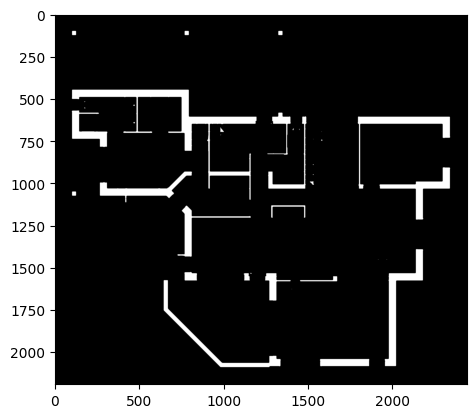

In [2]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread(images_path[0], cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(img, cmap="gray")
plt.show()

In [3]:
import numpy as np
from itertools import combinations


def detect_junctions_lsd(binary_image, skeleton):
    # Use LSD on the skeleton (or the binary directly)
    lsd = cv2.createLineSegmentDetector(cv2.LSD_REFINE_STD)
    lines, _, _, _ = lsd.detect(skeleton)

    if lines is None:
        return []

    lines = lines.reshape(-1, 4)  # [x1, y1, x2, y2]

    # ── Filter very short segments (noise) ──
    seg_lengths = np.sqrt(
        (lines[:, 2] - lines[:, 0]) ** 2 + (lines[:, 3] - lines[:, 1]) ** 2
    )
    lines = lines[seg_lengths > 20]

    # ── Compute pairwise intersections ──
    junctions = []
    for l1, l2 in combinations(lines, 2):
        pt = line_intersection(l1, l2)
        if pt is None:
            continue
        x, y = pt

        # Keep only intersections near both segments AND on/near the wall
        if (
            point_near_segment(pt, l1, tol=15)
            and point_near_segment(pt, l2, tol=15)
            and is_on_wall(pt, binary_image, radius=5)
        ):
            junctions.append((int(x), int(y)))

    return junctions


def line_intersection(l1, l2):
    """Intersection of two line segments treated as infinite lines."""
    x1, y1, x2, y2 = l1
    x3, y3, x4, y4 = l2
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if abs(denom) < 1e-6:
        return None  # parallel
    t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
    x = x1 + t * (x2 - x1)
    y = y1 + t * (y2 - y1)
    return (x, y)


def point_near_segment(pt, seg, tol=10):
    """Distance from point to line segment ≤ tol."""
    x, y = pt
    x1, y1, x2, y2 = seg
    dx, dy = x2 - x1, y2 - y1
    if dx == 0 and dy == 0:
        return False
    t = max(0, min(1, ((x - x1) * dx + (y - y1) * dy) / (dx * dx + dy * dy)))
    proj_x, proj_y = x1 + t * dx, y1 + t * dy
    return np.hypot(x - proj_x, y - proj_y) <= tol


def is_on_wall(pt, binary, radius=5):
    """Check if intersection point is actually inside/near wall pixels."""
    x, y = int(pt[0]), int(pt[1])
    h, w = binary.shape
    if not (0 <= x < w and 0 <= y < h):
        return False
    y1, y2 = max(0, y - radius), min(h, y + radius)
    x1, x2 = max(0, x - radius), min(w, x + radius)
    return np.any(binary[y1:y2, x1:x2] > 0)


def detect_junctions_polygon(binary):
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    junctions = []
    for cnt in contours:
        if cv2.contourArea(cnt) < 500:  # skip tiny noise
            continue

        # Adaptive epsilon based on perimeter
        epsilon = 0.005 * cv2.arcLength(cnt, closed=True)
        approx = cv2.approxPolyDP(cnt, epsilon, closed=True)

        for point in approx:
            junctions.append(tuple(point[0]))

    return junctions

In [4]:
# ── Step 1: Crop matplotlib border/axes ──
# Find bounding box of ALL white pixels, then add margin to exclude axis ticks
coords = np.column_stack(np.where(binary > 0))
y_min, x_min = coords.min(axis=0)
y_max, x_max = coords.max(axis=0)

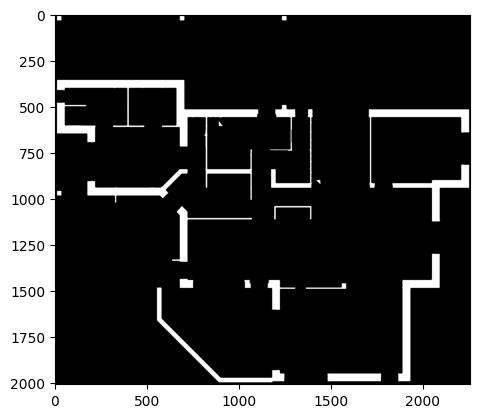

In [5]:
# Add small padding inward to exclude the outermost axis line
margin = -10
cropped = binary[y_min + margin : y_max - margin, x_min + margin : x_max - margin]

# ── Step 2: Remove small isolated noise dots ──
# Use area filtering via connected components
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cropped, connectivity=8)

# Calculate median area of components (floor plan walls will be large)
areas = stats[1:, cv2.CC_STAT_AREA]  # skip background

# Keep only components larger than threshold
# Use 1% of image area as minimum, or median-based threshold
min_area = max(100, np.median(areas) * 0.5) if len(areas) > 0 else 100

cleaned = np.zeros_like(cropped)
for label_id in range(1, num_labels):
    if stats[label_id, cv2.CC_STAT_AREA] >= min_area:
        cleaned[labels == label_id] = 255

plt.imshow(cleaned, cmap="gray")
plt.show()

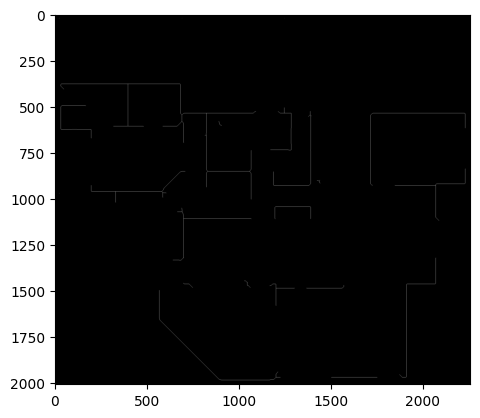

In [6]:
from skimage.morphology import skeletonize
from skimage import img_as_bool

# Skeletonize
skeleton = skeletonize(img_as_bool(cleaned))
skeleton = (skeleton * 255).astype(np.uint8)
plt.imshow(skeleton, cmap="gray")
plt.show()

In [7]:
from sklearn.cluster import DBSCAN


def cluster_junctions(coords, eps=10):
    if len(coords) == 0:
        return []
    clustering = DBSCAN(eps=eps, min_samples=1).fit(coords)
    junctions = []
    for label in set(clustering.labels_):
        cluster = coords[clustering.labels_ == label]
        centroid = cluster.mean(axis=0).astype(int)
        junctions.append(tuple(centroid))
    return junctions

In [8]:
def detect_all_junctions_combined(binary, skeleton):
    sources = []

    # 1. Skeleton branch points (T/X junctions, any angle)
    skel_bin = (skeleton > 0).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    kernel[1, 1] = 0
    neighbors = cv2.filter2D(skel_bin, -1, kernel)
    branch = np.column_stack(np.where((skel_bin == 1) & (neighbors >= 3)))[:, ::-1]
    sources.extend(branch.tolist())

    # 2. Polygon vertices from contours (corners at any angle)
    sources.extend(detect_junctions_polygon(binary))

    # 3. LSD intersections (catches diagonal-meets-orthogonal joins)
    sources.extend(detect_junctions_lsd(binary, skeleton))

    # Merge duplicates
    return cluster_junctions(np.array(sources), eps=15)

In [9]:
def visualize_numbered(binary, junctions, save_path=None, visualize=True):
    vis = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

    for i, (x, y) in enumerate(junctions):
        x, y = int(x), int(y)
        cv2.circle(vis, (x, y), 10, (0, 0, 255), -1)
        cv2.putText(
            vis,
            str(i),
            (x + 15, y - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 255),
            2,
        )

    if save_path:
        cv2.imwrite(save_path, vis)

    if visualize:
        plt.figure(figsize=(15, 10))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(f"Junctions: {len(junctions)}")
        plt.axis("off")
        plt.show()

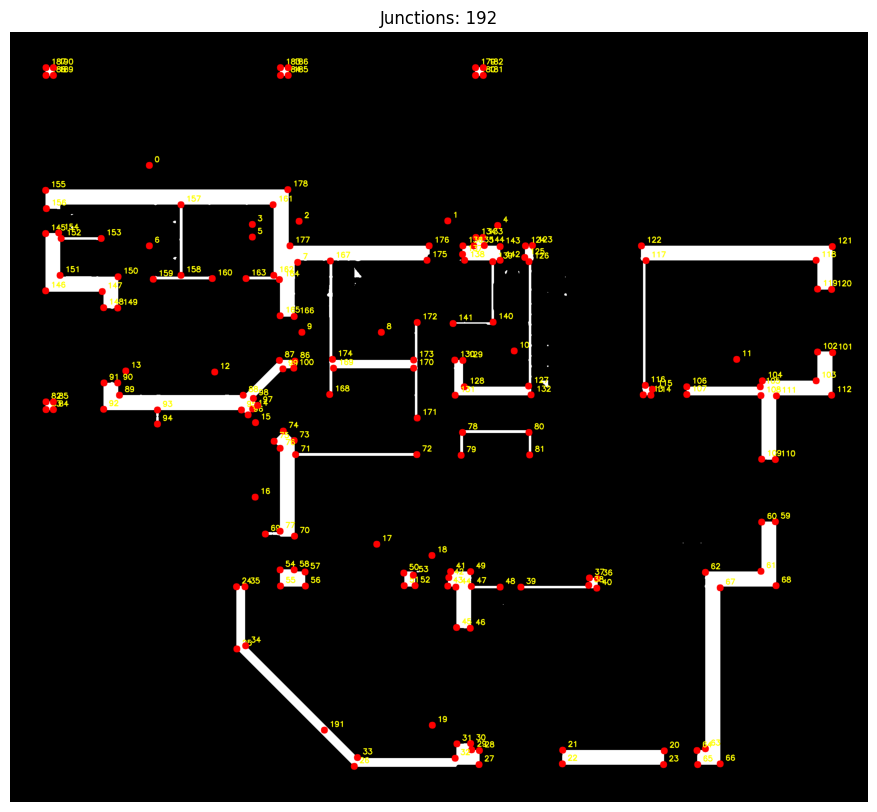

In [10]:
junctions = detect_all_junctions_combined(binary, skeleton)
visualize_numbered(binary, junctions)

In [11]:
import os
from pathlib import Path

output_dir = "../data/PNG/junctions"
os.makedirs(output_dir, exist_ok=True)
for img_path in images_path:
    fname = os.path.basename(img_path)
    new_path = Path(output_dir, fname)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    coords = np.column_stack(np.where(binary > 0))
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Add small padding inward to exclude the outermost axis line
    margin = 0
    cropped = binary[y_min + margin : y_max - margin, x_min + margin : x_max - margin]

    # ── Step 2: Remove small isolated noise dots ──
    # Use area filtering via connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        cropped, connectivity=8
    )

    # Calculate median area of components (floor plan walls will be large)
    areas = stats[1:, cv2.CC_STAT_AREA]  # skip background

    # Keep only components larger than threshold
    # Use 1% of image area as minimum, or median-based threshold
    min_area = max(100, np.median(areas) * 0.5) if len(areas) > 0 else 100

    cleaned = np.zeros_like(cropped)
    for label_id in range(1, num_labels):
        if stats[label_id, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == label_id] = 255

    skeleton = skeletonize(img_as_bool(cleaned))
    skeleton = (skeleton * 255).astype(np.uint8)
    junctions = detect_all_junctions_combined(binary, skeleton)
    visualize_numbered(binary, junctions, save_path=new_path, visualize=False)